# Module 7: Advanced Curve Dynamics & Stochastic Simulation

In this module, we transition from deterministic pricing to probabilistic models. We will:
1. Fetch 10 years of historical Treasury yield curve data.
2. Perform **Principal Component Analysis (PCA)** to decompose the curve movements into empirical factors (Level, Steepness, Curvature).
3. **Calibrate** stochastic short-rate models (Vasicek and CIR) to historical rates.
4. Run a **Monte Carlo Engine** to simulate thousands of future yield curve paths.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

sys.path.insert(0, os.path.abspath(".."))
print("CWD:", os.getcwd())
print("SYS.PATH:", sys.path)

import datetime  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402

from src.data.fred import FredFetcher  # noqa: E402
from src.curve.pca import YieldCurvePCA  # noqa: E402
from src.models.stochastic import CIRModel  # noqa: E402
from src.models.calibration import calibrate_vasicek, calibrate_cir  # noqa: E402
from src.models.monte_carlo import MonteCarloEngine  # noqa: E402
from src.utils.plotting import set_theme  # noqa: E402

set_theme()

CWD: /Users/mukundankit/Documents/Finance/bond_modelling/notebooks
SYS.PATH: ['/Users/mukundankit/Documents/Finance/bond_modelling', '/Users/mukundankit/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python312.zip', '/Users/mukundankit/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12', '/Users/mukundankit/.local/share/uv/python/cpython-3.12-macos-aarch64-none/lib/python3.12/lib-dynload', '', '/Users/mukundankit/Documents/Finance/bond_modelling/.venv/lib/python3.12/site-packages', '/Users/mukundankit/Documents/Finance/bond_modelling/src']


## 1. Fetching Historical Treasury Data

We will use our `TreasuryFetcher` to grab historical yield curves. To do PCA over a meaningful period, let's look at the last 10 years of data.


In [2]:
# Fetch data (cached if previously run)
fetcher = FredFetcher()
end_date = datetime.date(2023, 12, 31)
start_date = datetime.date(2013, 1, 1)

# In practice, fetching 10 years of daily curves from the Treasury API directly can take a while
# and might hit rate limits. To keep this notebook fast, we'll fetch end-of-month curves.

dates = pd.date_range(start_date, end_date, freq="ME").date
curves = []
valid_dates = []

for d in dates:
    try:
        curve = fetcher.fetch_yield_curve(d)
        curves.append(curve)
        valid_dates.append(d)
    except Exception:
        # Holiday or weekend
        pass

df_yields = pd.DataFrame(curves, index=valid_dates)
df_yields = df_yields.dropna(
    axis=1, thresh=len(df_yields) * 0.9
)  # Drop if more than 10% missing
df_yields = df_yields.interpolate(method="linear", limit_direction="both")
df_yields = df_yields.bfill().ffill()  # Just in case interpolation misses edges
print("Yields shape:", df_yields.shape)
df_yields.head()

Failed to fetch from FRED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO
Exception:
HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=DGS3MO (Caused by NameResolutionError("HTTPSConnection(host='fred.stlouisfed.org', port=443): Failed to resolve 'fred.stlouisfed.org' ([Errno 8] nodename nor servname provided, or not known)"))


Failed to fetch from FRED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO
Exception:
HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=DGS3MO (Caused by NameResolutionError("HTTPSConnection(host='fred.stlouisfed.org', port=443): Failed to resolve 'fred.stlouisfed.org' ([Errno 8] nodename nor servname provided, or not known)"))


Failed to fetch from FRED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO
Exception:
HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=DGS3MO (Caused by NameResolutionError("HTTPSConnection(host='fred.stlouisfed.org', port=443): Failed to resolve 'fred.stlouisfed.org' ([Errno 8] nodename nor servname provided, or not known)"))


Failed to fetch from FRED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO
Exception:
HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=DGS3MO (Caused by NameResolutionError("HTTPSConnection(host='fred.stlouisfed.org', port=443): Failed to resolve 'fred.stlouisfed.org' ([Errno 8] nodename nor servname provided, or not known)"))


Failed to fetch from FRED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO
Exception:
HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=DGS3MO (Caused by NameResolutionError("HTTPSConnection(host='fred.stlouisfed.org', port=443): Failed to resolve 'fred.stlouisfed.org' ([Errno 8] nodename nor servname provided, or not known)"))


...

Failed to fetch from FRED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO
Exception:
HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=DGS3MO (Caused by NameResolutionError("HTTPSConnection(host='fred.stlouisfed.org', port=443): Failed to resolve 'fred.stlouisfed.org' ([Errno 8] nodename nor servname provided, or not known)"))


Failed to fetch from FRED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO
Exception:
HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=DGS3MO (Caused by NameResolutionError("HTTPSConnection(host='fred.stlouisfed.org', port=443): Failed to resolve 'fred.stlouisfed.org' ([Errno 8] nodename nor servname provided, or not known)"))


Failed to fetch from FRED: Unable to read URL: https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS3MO
Exception:
HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=DGS3MO (Caused by NameResolutionError("HTTPSConnection(host='fred.stlouisfed.org', port=443): Failed to resolve 'fred.stlouisfed.org' ([Errno 8] nodename nor servname provided, or not known)"))


Yields shape: (115, 6)


,0.25,1.00,2.00,5.00,10.00,30.00
2013-01-31,0.0007,0.0015,0.0027,0.0088,0.0202,0.0317
2013-02-28,0.0011,0.0017,0.0025,0.0077,0.0189,0.0310
2013-03-31,0.0007,0.0014,0.0025,0.0077,0.0187,0.0310
2013-04-30,0.0005,0.0011,0.0022,0.0068,0.0170,0.0288
2013-05-31,0.0004,0.0014,0.0030,0.0105,0.0216,0.0330


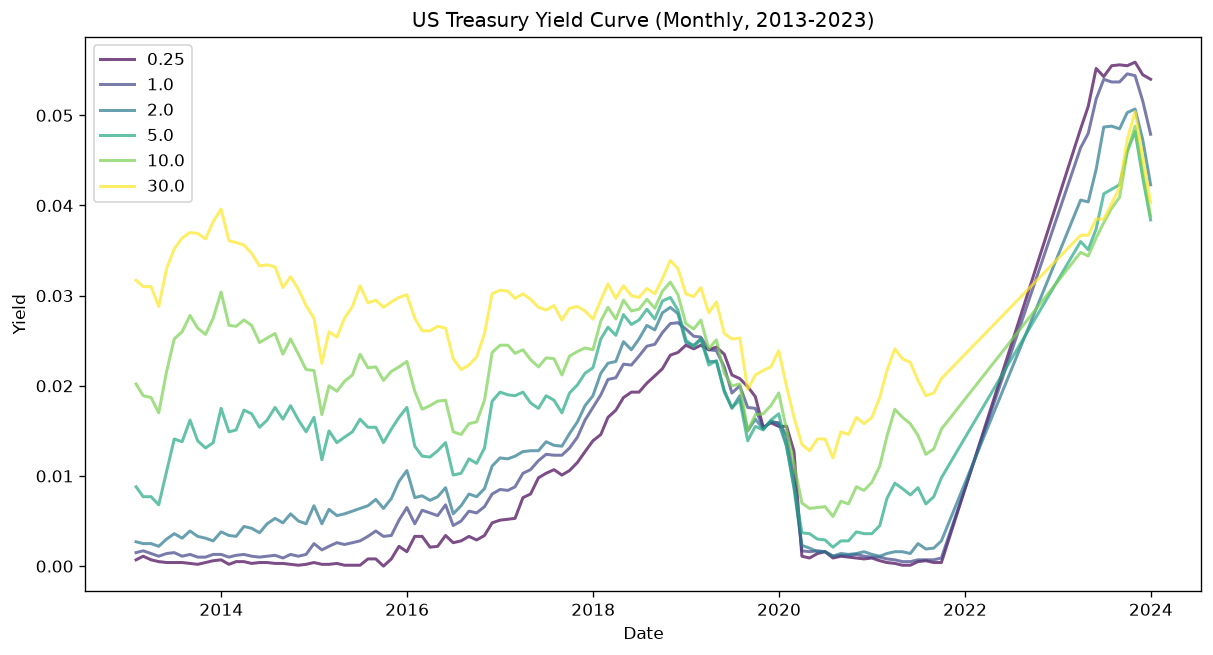

In [3]:
df_yields.plot(figsize=(12, 6), colormap="viridis", alpha=0.7)
plt.title("US Treasury Yield Curve (Monthly, 2013-2023)")
plt.ylabel("Yield")
plt.xlabel("Date")
plt.show()

## 2. Principal Component Analysis (PCA)

We will decompose the historical yield curve to extract the latent factors driving its movement.


In [4]:
pca = YieldCurvePCA(n_components=3)
pca.fit(df_yields)

print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total Explained Variance: {np.sum(pca.explained_variance_ratio_):.4f}")

Explained Variance Ratio: [0.90875095 0.08158053 0.00835382]
Total Explained Variance: 0.9987


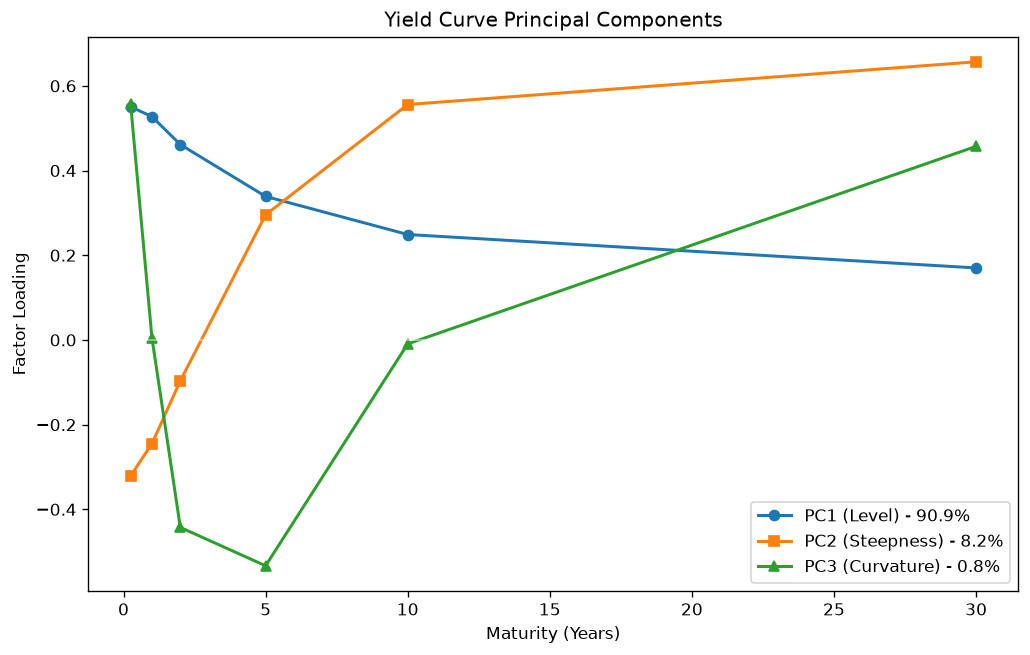

In [5]:
# Plot the principal components (factor loadings)
maturities = df_yields.columns.values

plt.figure(figsize=(10, 6))
plt.plot(
    maturities,
    pca.components_[0],
    marker="o",
    label=f"PC1 (Level) - {pca.explained_variance_ratio_[0]:.1%}",
)
plt.plot(
    maturities,
    pca.components_[1],
    marker="s",
    label=f"PC2 (Steepness) - {pca.explained_variance_ratio_[1]:.1%}",
)
plt.plot(
    maturities,
    pca.components_[2],
    marker="^",
    label=f"PC3 (Curvature) - {pca.explained_variance_ratio_[2]:.1%}",
)

plt.axhline(0, color="white", linewidth=1, alpha=0.5)
plt.title("Yield Curve Principal Components")
plt.xlabel("Maturity (Years)")
plt.ylabel("Factor Loading")
plt.legend()
plt.show()

## 3. Calibrating Stochastic Models (Vasicek and CIR)

Let's calibrate the Vasicek and CIR models to the 1-Year Treasury rate.


In [6]:
# 1-Year Treasury Yields
r_1y = df_yields[1.0].values

# Calibrate Vasicek
dt = 1 / 12  # Monthly data
a_v, b_v, sigma_v = calibrate_vasicek(r_1y, dt)
print(
    f"Vasicek Calibration -> Speed (a): {a_v:.4f}, Mean (b): {b_v:.4f}, Volatility (sigma): {sigma_v:.4f}"
)

# Calibrate CIR
a_c, b_c, sigma_c = calibrate_cir(r_1y, dt)
print(
    f"CIR Calibration     -> Speed (a): {a_c:.4f}, Mean (b): {b_c:.4f}, Volatility (sigma): {sigma_c:.4f}"
)

Vasicek Calibration -> Speed (a): 0.2721, Mean (b): 0.0296, Volatility (sigma): 0.0154
CIR Calibration     -> Speed (a): 0.8563, Mean (b): 0.0174, Volatility (sigma): 0.4875


## 4. Monte Carlo Simulation

Using the calibrated CIR model, we will simulate 1,000 future paths of the 1-year rate over the next 5 years.


/Users/mukundankit/Documents/Finance/bond_modelling/src/models/stochastic.py:63: UserWarning: Feller condition (2ab > sigma^2) is not satisfied. Rates may hit zero.
  warnings.warn(  # noqa: B028


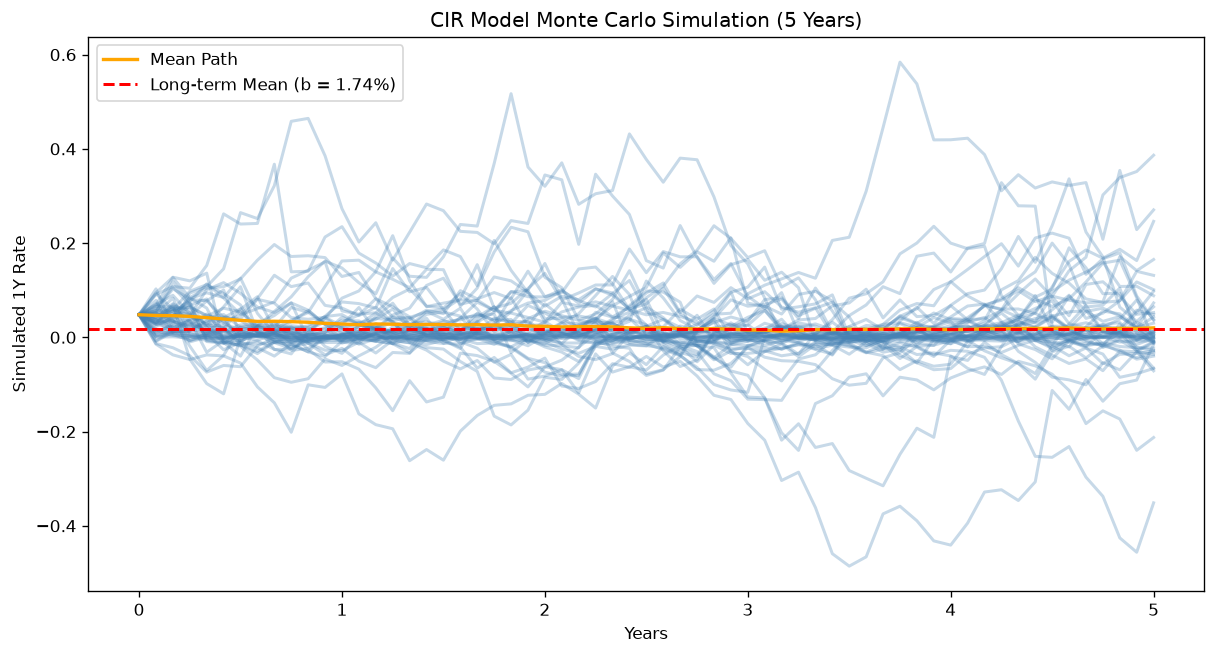

In [7]:
# Initialize models
cir = CIRModel(a_c, b_c, sigma_c)

# Simulate 1,000 paths over 5 years
mc_engine = MonteCarloEngine(
    cir, n_paths=1000, n_steps=60, seed=42
)  # 60 months = 5 years
r0 = r_1y[-1]  # Starting rate (latest observation)

paths = mc_engine.simulate_paths(r0=r0, T=5.0)

plt.figure(figsize=(12, 6))
# Plot first 50 paths to avoid crowding
plt.plot(np.linspace(0, 5, 61), paths[:, :50], alpha=0.3, color="steelblue")
plt.plot(
    np.linspace(0, 5, 61),
    np.mean(paths, axis=1),
    color="orange",
    linewidth=2,
    label="Mean Path",
)
plt.axhline(b_c, color="red", linestyle="--", label=f"Long-term Mean (b = {b_c:.2%})")

plt.title("CIR Model Monte Carlo Simulation (5 Years)")
plt.xlabel("Years")
plt.ylabel("Simulated 1Y Rate")
plt.legend()
plt.show()